# Entregable 1 - Seminario de Ciencia de Datos
## Análisis Exploratorio y Tratamiento de Datos

**Dataset:** Heart Disease - Cleveland (UCI Machine Learning Repository)
**Autor:** Jaime Alzate
**Programa:** Desarrollo de Software - 9° semestre

---

### ¿Por qué este dataset?

El profesor pidió que cumpliera con 3 cosas:
- Tener nulos
- Tener outliers
- Tener al menos 10 variables predictoras

Heart Disease cumple todo eso. Tiene 303 registros y 14 variables sobre pacientes
(edad, colesterol, presión, etc), y la idea es predecir si la persona tiene o no
enfermedad cardíaca. Me pareció un problema interesante porque es de salud pública.

### Variables del dataset

| Variable | Qué es |
|----------|--------|
| age | Edad |
| sex | Sexo (1=hombre, 0=mujer) |
| cp | Tipo de dolor en el pecho (1-4) |
| trestbps | Presión arterial en reposo |
| chol | Colesterol |
| fbs | Glicemia en ayunas mayor a 120 |
| restecg | Resultado del electro en reposo |
| thalach | Frecuencia cardíaca máxima |
| exang | Angina con el ejercicio |
| oldpeak | Depresión ST con el ejercicio |
| slope | Pendiente del segmento ST |
| ca | Vasos coloreados por fluoroscopia |
| thal | Talasemia |
| num | Diagnóstico original (0-4) |
| target | Lo que voy a crear: 0=sano, 1=enfermo |

In [1]:
# Importo las librerias que voy a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Para imputacion
from sklearn.experimental import enable_iterative_imputer  # esto hay que importarlo antes
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.linear_model import BayesianRidge

# Esto es para que no salgan warnings molestos
import warnings
warnings.filterwarnings('ignore')

# Configuracion de los graficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## I. Análisis Descriptivo y de Calidad

Primero cargo el dataset. Hay un detalle: los nulos en este dataset vienen
marcados como `?` (no como NaN), entonces hay que decirle a pandas que los
trate como faltantes con `na_values='?'`.

In [2]:
# URL del dataset en UCI (asi el notebook es autocontenido y se puede correr en Colab)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Los nombres de las columnas estan en la documentacion del UCI
columnas = ['age','sex','cp','trestbps','chol','fbs','restecg',
            'thalach','exang','oldpeak','slope','ca','thal','num']

# Cargar el dataset (header=None porque no tiene encabezados, na_values='?' para detectar nulos)
df = pd.read_csv(url, header=None, names=columnas, na_values='?')

# Creo la variable target binaria
# num va de 0 a 4 (gravedad), yo solo quiero saber si tiene o no
df['target'] = (df['num'] > 0).astype(int)

print('Dimensiones:', df.shape)
df.head()

Dimensiones: (303, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [3]:
# Reviso los tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
 14  target    303 non-null    int64  
dtypes: float64(13), int64(2)
memory usage: 35.6 KB


In [4]:
# Estadisticos descriptivos
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.94,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,1.23,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,2.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,4.00,1.00


Ya con esta tabla veo varias cosas interesantes:
- La variable `ca` tiene solo 299 valores (faltan 4)
- La variable `thal` tiene 301 (faltan 2)
- El colesterol va de 126 a 564 mg/dl, ese 564 se ve raro (posible outlier)
- En `oldpeak` la media (1.04) es mayor que la mediana (0.80) → sesgo a la derecha

In [5]:
# Verifico el balance de las clases del target
df['target'].value_counts(normalize=True).round(2)

target
0    0.54
1    0.46
Name: proportion, dtype: float64

54% sin enfermedad y 46% con enfermedad. No hay un desbalance fuerte
entonces no necesito tecnicas de rebalanceo.

## II. Evaluación de la Calidad - Distribuciones y Normalidad

Para revisar normalidad voy a usar 3 cosas:
1. Histogramas con curva de densidad (para ver la forma)
2. Q-Q plots (para comparar con la normal)
3. Prueba de Shapiro-Wilk (formal, con p-valor)

Para esto solo me interesan las variables numericas continuas, no las categoricas
codificadas como numeros (como sex o cp).

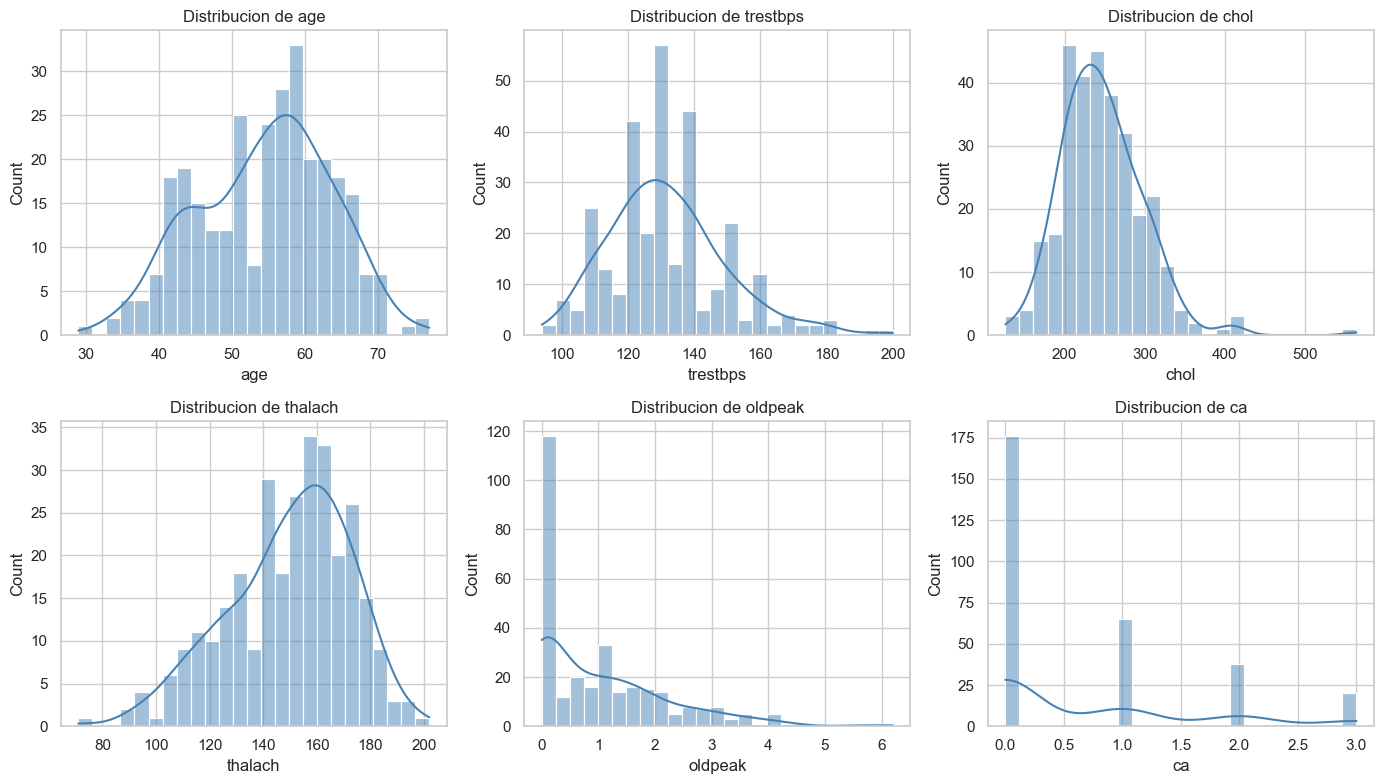

In [6]:
# Defino las variables numericas continuas que voy a analizar
variables_numericas = ['age','trestbps','chol','thalach','oldpeak','ca']

# Hago una grilla de histogramas con KDE
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), variables_numericas):
    # dropna() porque si hay nulos da error
    sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=25, color='steelblue')
    ax.set_title('Distribucion de ' + col)
plt.tight_layout()
plt.show()

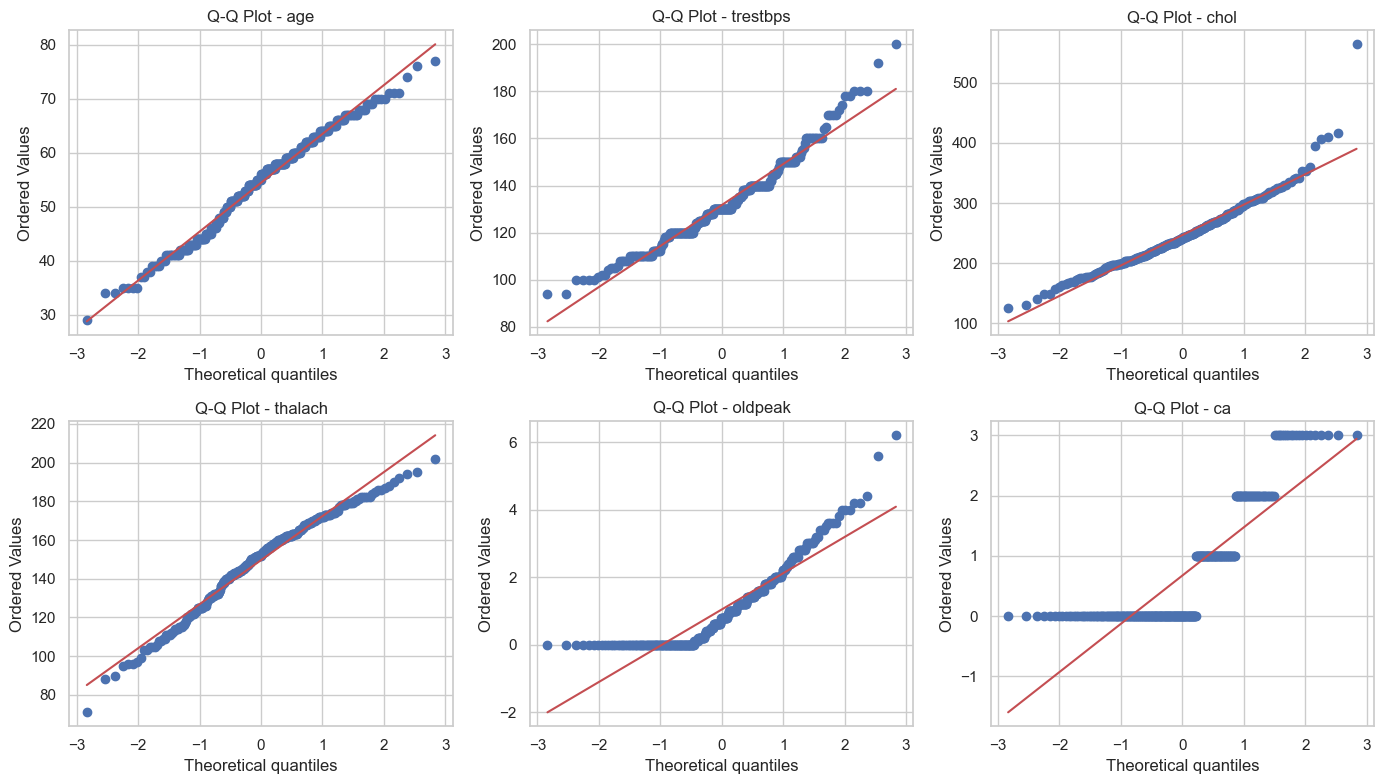

In [7]:
# Ahora los Q-Q plots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), variables_numericas):
    stats.probplot(df[col].dropna(), dist='norm', plot=ax)
    ax.set_title('Q-Q Plot - ' + col)
plt.tight_layout()
plt.show()

En los Q-Q plots se ve que casi ninguna sigue la diagonal. Las que más se
desvian son `oldpeak` y `ca` (tienen forma de escalera porque son casi discretas).

Ahora la prueba formal:

In [8]:
# Prueba de Shapiro-Wilk para cada variable
# H0: la variable es normal
# Si p < 0.05 → rechazo H0 → no es normal

resultados_shapiro = []

for col in variables_numericas:
    # shapiro devuelve (estadistico, p-valor)
    W, p_valor = stats.shapiro(df[col].dropna())

    if p_valor < 0.05:
        decision = 'Rechaza H0 (no es normal)'
    else:
        decision = 'No rechaza H0 (es normal)'

    resultados_shapiro.append({
        'variable': col,
        'W': round(W, 4),
        'p_valor': round(p_valor, 6),
        'decision': decision
    })

shapiro_df = pd.DataFrame(resultados_shapiro)
shapiro_df

,variable,W,p_valor,decision
0,age,0.9865,0.006069,Rechaza H0 (no es normal)
1,trestbps,0.9665,0.000002,Rechaza H0 (no es normal)
2,chol,0.9473,0.000000,Rechaza H0 (no es normal)
3,thalach,0.9765,0.000070,Rechaza H0 (no es normal)
4,oldpeak,0.8442,0.000000,Rechaza H0 (no es normal)
5,ca,0.7187,0.000000,Rechaza H0 (no es normal)


Las 6 variables rechazan H0, ninguna es normal. Esto es importante porque:
- Para imputar voy a usar la **mediana**, no la media
- En el segundo entregable hay que tener cuidado con tecnicas que asumen normalidad

## III. Detección y Tratamiento de Ausentes

### Conteo de nulos por columna

In [9]:
# Cuento los nulos por columna
nulos = df.isnull().sum()
porcentaje = (df.isnull().sum() / len(df) * 100).round(2)

tabla_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje': porcentaje
})

# Me quedo solo con las que tienen nulos
tabla_nulos = tabla_nulos[tabla_nulos['nulos'] > 0]
tabla_nulos

,nulos,porcentaje
ca,4,1.32
thal,2,0.66


Solo 6 nulos en total (4 en `ca`, 2 en `thal`). Es poco, asi que no vale la
pena eliminar filas, mejor imputar.

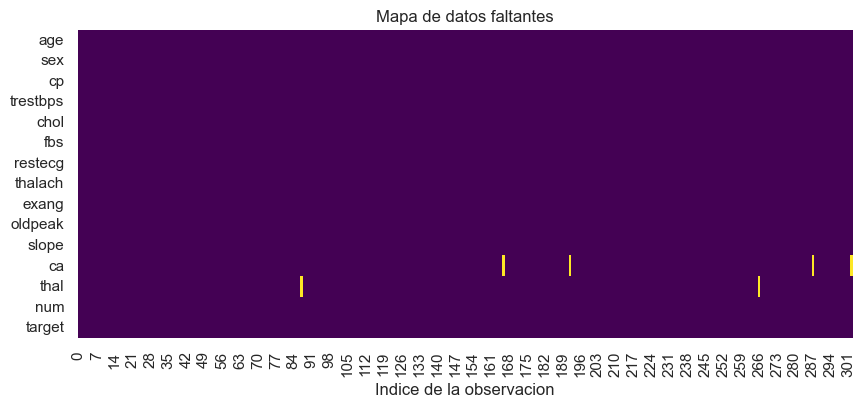

In [10]:
# Mapa de calor de donde estan los nulos
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull().T, cbar=False, cmap='viridis')
plt.title('Mapa de datos faltantes')
plt.xlabel('Indice de la observacion')
plt.show()

### Prueba de Rachas (Wald-Wolfowitz)

Esta prueba sirve para ver si los nulos aparecen de forma aleatoria o no.

- H0: la secuencia de nulos es aleatoria (MCAR)
- Si rechazo H0: hay un patron en los nulos (MAR o MNAR)

La logica es: convierto el patron de nulos en una secuencia binaria (1 si es
nulo, 0 si no), cuento las "rachas" (cambios entre 0 y 1) y comparo con lo
esperado si fueran aleatorios.

In [11]:
# Implemento la prueba de rachas a mano
# (scipy no la tiene directa, statsmodels si pero quise hacerla yo)

def prueba_rachas(secuencia):
    """
    Prueba de rachas de Wald-Wolfowitz.
    secuencia: array de 0s y 1s
    Retorna: z, p_valor, numero_rachas
    """
    seq = np.array(secuencia)

    # n1 = numero de 1s, n2 = numero de 0s
    n1 = (seq == 1).sum()
    n2 = (seq == 0).sum()
    n = n1 + n2

    # Si alguno es 0 no puedo hacer la prueba
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan, 0

    # Conto las rachas: una racha es cuando cambia de 0 a 1 o viceversa
    # 1 + (numero de cambios)
    cambios = (seq[1:] != seq[:-1]).sum()
    rachas = 1 + cambios

    # Media y varianza esperadas si fuera aleatorio
    media_esperada = (2 * n1 * n2) / n + 1
    varianza = (2 * n1 * n2 * (2 * n1 * n2 - n)) / (n**2 * (n - 1))

    if varianza <= 0:
        return np.nan, np.nan, rachas

    # Estadistico z
    z = (rachas - media_esperada) / np.sqrt(varianza)

    # p-valor (dos colas)
    p_valor = 2 * (1 - stats.norm.cdf(abs(z)))

    return z, p_valor, rachas


# Aplico la prueba a las variables con nulos
resultados_rachas = []

for col in tabla_nulos.index:
    # Convierto a secuencia binaria: 1 = nulo, 0 = no nulo
    secuencia_binaria = df[col].isnull().astype(int).values

    z, p_valor, rachas = prueba_rachas(secuencia_binaria)

    if p_valor >= 0.05:
        decision = 'Aleatorio (MCAR)'
    else:
        decision = 'No aleatorio (MAR/MNAR)'

    resultados_rachas.append({
        'variable': col,
        'rachas': rachas,
        'z': round(z, 4),
        'p_valor': round(p_valor, 4),
        'decision': decision
    })

pd.DataFrame(resultados_rachas)

,variable,rachas,z,p_valor,decision
0,ca,8,-2.1068,0.0351,No aleatorio (MAR/MNAR)
1,thal,5,0.1335,0.8938,Aleatorio (MCAR)


Resultado interesante: los nulos de `ca` no son aleatorios (p < 0.05), pero
los de `thal` sí lo parecen. Eso refuerza la idea de usar imputacion mas
sofisticada en `ca` (no solo poner la mediana).

## IV. Tratamiento de Outliers (Método IQR)

Aplico la regla del 1.5*IQR:
- Calculo Q1 y Q3
- IQR = Q3 - Q1
- Limite inferior = Q1 - 1.5*IQR
- Limite superior = Q3 + 1.5*IQR
- Todo lo que este fuera de esos limites es outlier

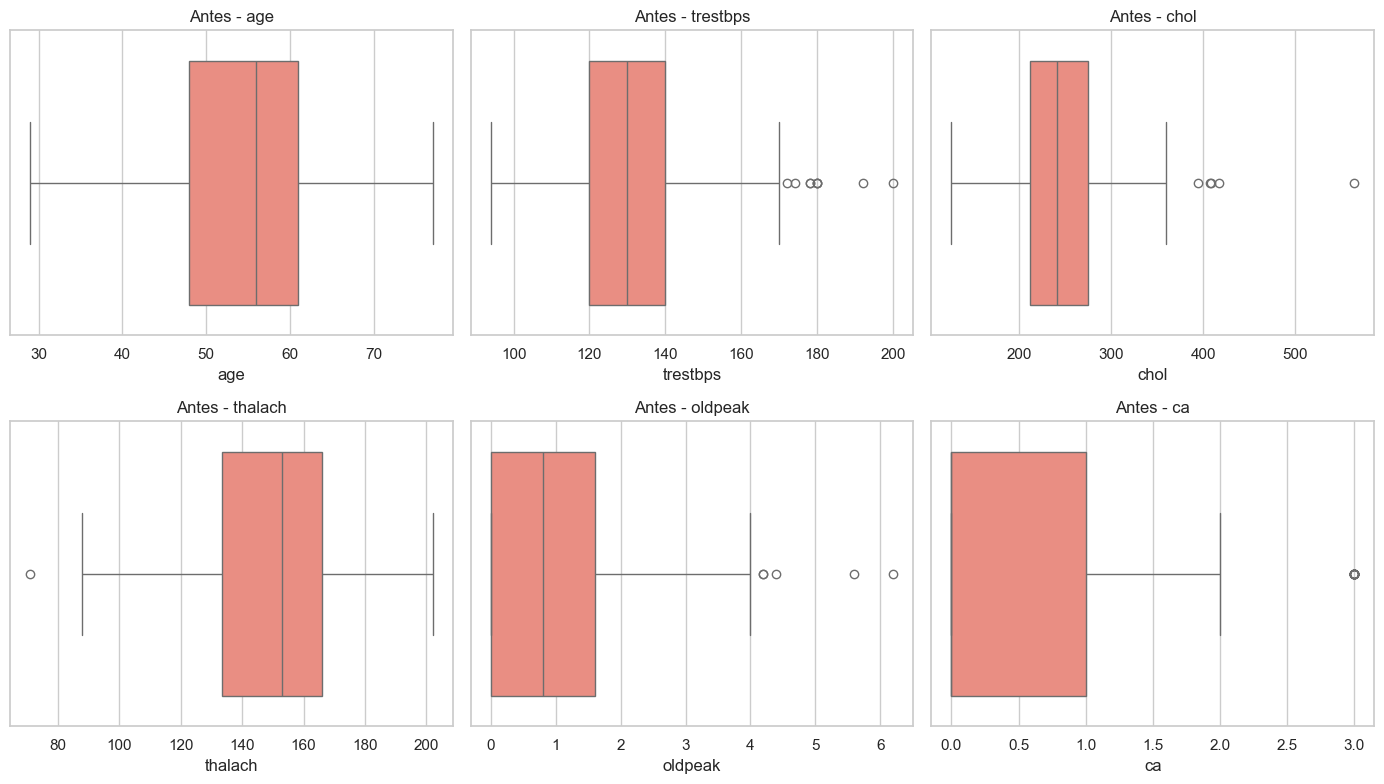

In [12]:
# Primero veo los boxplots antes de tratar nada
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), variables_numericas):
    sns.boxplot(x=df[col].dropna(), ax=ax, color='salmon')
    ax.set_title('Antes - ' + col)
plt.tight_layout()
plt.show()

In [13]:
# Calculo los limites y cuento outliers
df_sin_outliers = df.copy()
resumen_outliers = []

for col in variables_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    # Cuento cuantos outliers hay
    es_outlier = (df[col] < limite_inf) | (df[col] > limite_sup)
    n_outliers = es_outlier.sum()

    # Aplico capping: reemplazo los valores fuera de rango por el limite
    df_sin_outliers[col] = df_sin_outliers[col].clip(lower=limite_inf, upper=limite_sup)

    resumen_outliers.append({
        'variable': col,
        'lim_inf': round(limite_inf, 2),
        'lim_sup': round(limite_sup, 2),
        'n_outliers': int(n_outliers)
    })

pd.DataFrame(resumen_outliers)

,variable,lim_inf,lim_sup,n_outliers
0,age,28.50,80.50,0
1,trestbps,90.00,170.00,9
2,chol,115.00,371.00,5
3,thalach,84.75,214.75,1
4,oldpeak,-2.40,4.00,5
5,ca,-1.50,2.50,20


**¿Por qué capping y no eliminar?**

40 outliers en total. Si los elimino pierdo el 13% del dataset, y como solo
tengo 303 registros esto es mucho. Ademas, valores como un colesterol de 564
pueden ser reales (pacientes con condiciones graves), no errores.

El capping reemplaza el valor extremo por el limite del IQR, conservando la
fila pero atenuando el efecto.

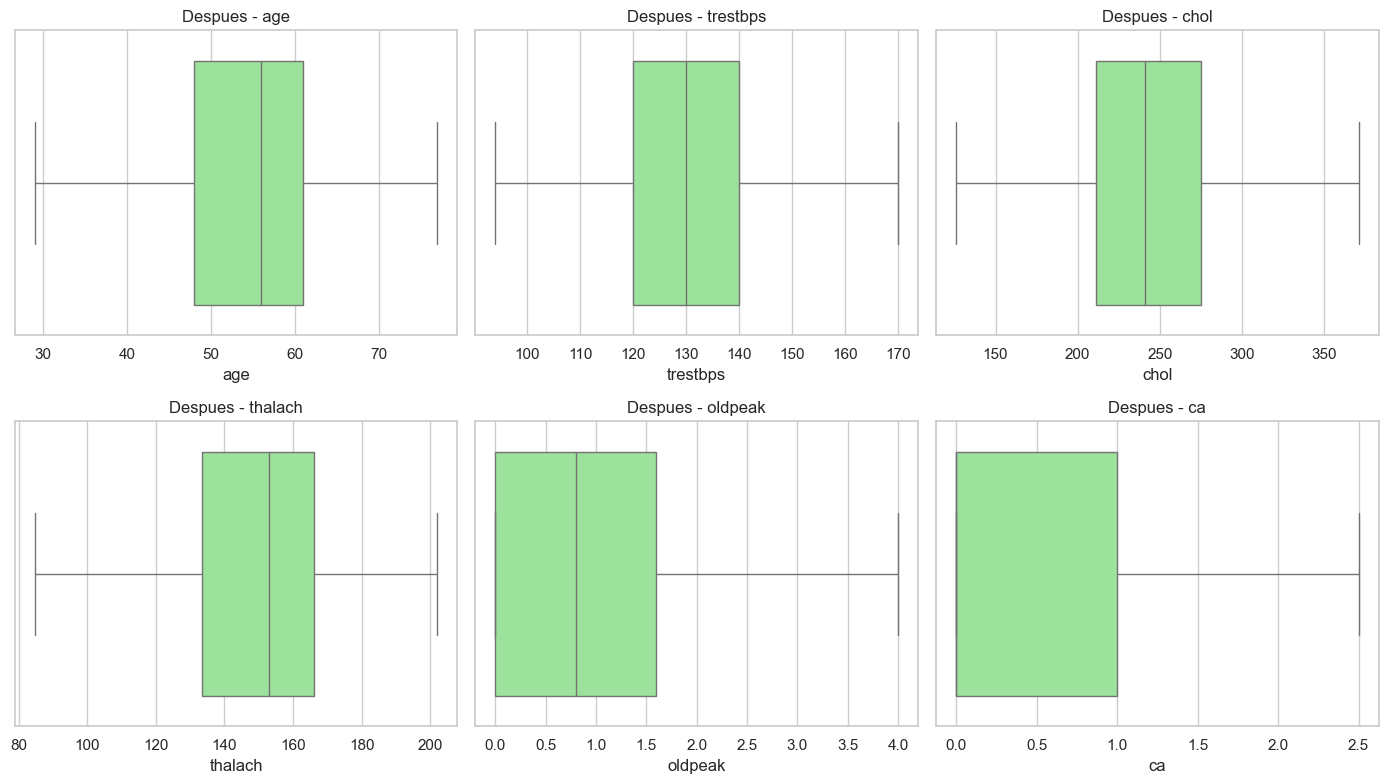

In [14]:
# Boxplots despues del capping
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), variables_numericas):
    sns.boxplot(x=df_sin_outliers[col].dropna(), ax=ax, color='lightgreen')
    ax.set_title('Despues - ' + col)
plt.tight_layout()
plt.show()

## V. Imputación Comparativa

Voy a comparar 2 tecnicas de imputacion sobre la variable `ca` (es la que
tiene mas nulos):

1. **Imputacion simple por mediana** - la mas basica
2. **Imputacion por regresion** - usa el resto de variables para predecir el valor

In [15]:
# Tecnica 1: imputacion simple por mediana
df_mediana = df_sin_outliers.copy()

imputador_simple = SimpleImputer(strategy='median')
df_mediana[variables_numericas] = imputador_simple.fit_transform(df_mediana[variables_numericas])

print('Nulos en ca despues de imputacion por mediana:', df_mediana['ca'].isnull().sum())

Nulos en ca despues de imputacion por mediana: 0


In [16]:
# Tecnica 2: imputacion por regresion (IterativeImputer)
# Usa BayesianRidge como modelo para predecir cada valor faltante
df_regresion = df_sin_outliers.copy()

imputador_regresion = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=20,
    random_state=42  # para que sea reproducible
)
df_regresion[variables_numericas] = imputador_regresion.fit_transform(df_regresion[variables_numericas])

print('Nulos en ca despues de imputacion por regresion:', df_regresion['ca'].isnull().sum())

Nulos en ca despues de imputacion por regresion: 0


In [17]:
# Comparo los estadisticos de las 3 versiones
comparacion = pd.DataFrame({
    'original (con nulos)': df['ca'].describe(),
    'imp_mediana': df_mediana['ca'].describe(),
    'imp_regresion': df_regresion['ca'].describe()
})

comparacion.round(4)

,original (con nulos),imp_mediana,imp_regresion
count,299.0000,303.0000,303.0000
mean,0.6722,0.6304,0.6351
std,0.9374,0.8566,0.8547
min,0.0000,0.0000,-0.0478
25%,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000
75%,1.0000,1.0000,1.0000
max,3.0000,2.5000,2.5000


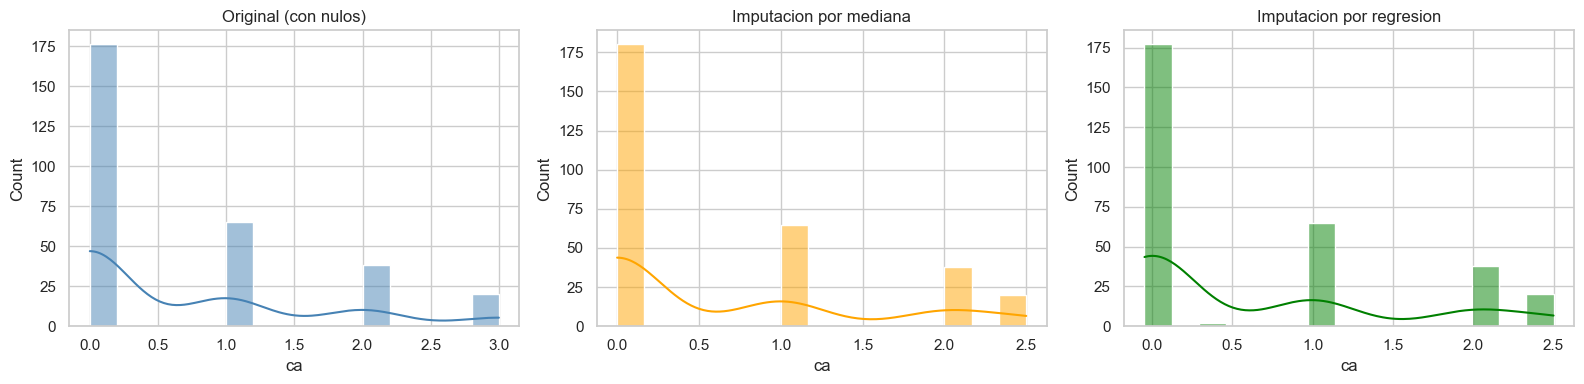

In [18]:
# Visualizo las distribuciones lado a lado
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['ca'].dropna(), kde=True, ax=axes[0], bins=15, color='steelblue')
axes[0].set_title('Original (con nulos)')

sns.histplot(df_mediana['ca'], kde=True, ax=axes[1], bins=15, color='orange')
axes[1].set_title('Imputacion por mediana')

sns.histplot(df_regresion['ca'], kde=True, ax=axes[2], bins=15, color='green')
axes[2].set_title('Imputacion por regresion')

plt.tight_layout()
plt.show()

**Conclusión:** la imputacion por mediana solo agrega 4 ceros más, lo que
refuerza el sesgo de la variable hacia el cero. La imputacion por regresion
predice valores continuos teniendo en cuenta las demas variables, lo que es
mas realista.

Voy a usar el dataset imputado por regresion para el Entregable 2.

## Cierre

### Matriz de correlación del dataset preprocesado

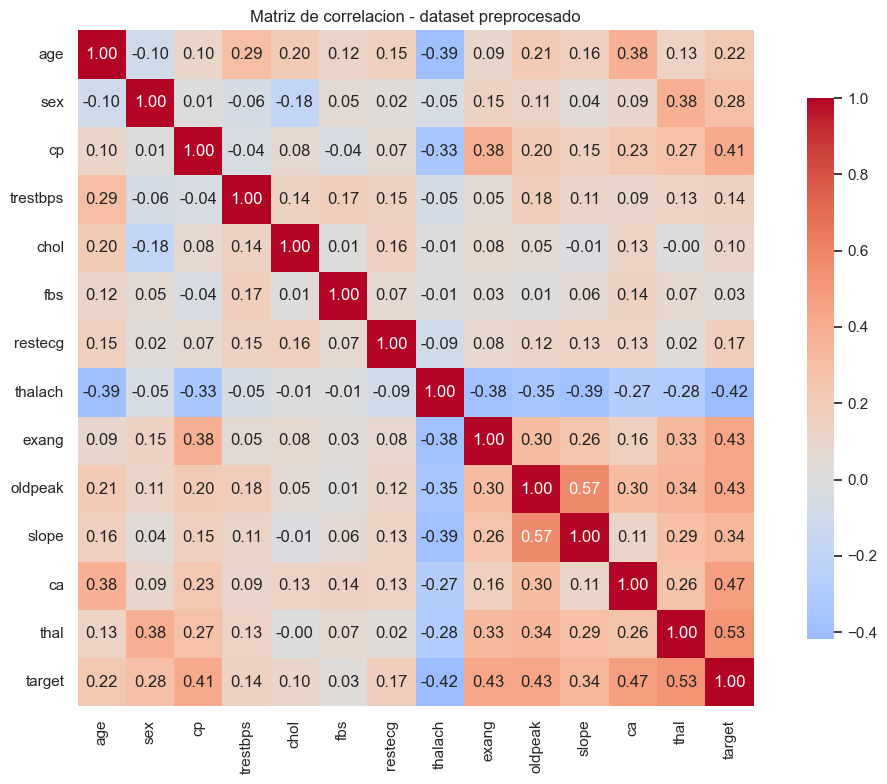

In [19]:
# Matriz de correlacion final
plt.figure(figsize=(11, 8))
correlacion = df_regresion.drop(columns=['num']).corr()
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlacion - dataset preprocesado')
plt.tight_layout()
plt.show()

In [20]:
# Dataset final listo para el Entregable 2
df_final = df_regresion.drop(columns=['num']).copy()

print('Forma final del dataset:', df_final.shape)
print('Columnas:', df_final.columns.tolist())
df_final.head()

Forma final del dataset: (303, 14)
Columnas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,2.5,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Resumen de hallazgos

1. **Normalidad:** las 6 variables continuas analizadas no son normales (Shapiro-Wilk rechaza H0)
2. **Nulos:** solo 6 en total (4 en `ca`, 2 en `thal`). En `ca` el patron no es aleatorio
3. **Outliers:** 40 detectados, tratados por capping para no perder filas
4. **Imputacion:** la imputacion por regresion bayesiana funciona mejor que la simple
5. El dataset queda listo para PCA y modelado en el Entregable 2